## Reliability总图

In [ ]:
#!/usr/bin/env python3
%matplotlib inline

"""
Confidence & Reliability Figure
=================================
Three-panel figure for Nature submission using router_x_maxpe as joint confidence:
  a. Per-bucket performance bar chart
  b. Coverage-Accuracy curve (continuous)
  c. Performance vs margin threshold (discrete, monotonically increasing)

Output: confidence_reliability.pdf / .png
"""

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

PRED_PATH  = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x/predictions.parquet"
#PRED_PATH  = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3_seed42_with_expert_margin/predictions.parquet"
OUT_PATH   = "confidence_reliability"
MARGIN_COL = "router_x_maxpe"
#PRED_COL   = "pred_top1"
PRED_COL = "pred_soft"
N_STEPS    = 200

# Nature double-column: 180mm = 7.09in
FIG_W = 7.09
FIG_H = 5.5

# Colors
C_BAL = "#378ADD"
C_F1  = "#1D9E75"
C_ACC = "#E24B4A"
C_BAR = "#B5D4F4"
C_THR = "#D4700A"
C_REF = "#888780"


# ── Load ──────────────────────────────────────────────────────────────────

df = pd.read_parquet(PRED_PATH)
all_classes = sorted(df["label"].unique())
N = len(df)
print(f"Loaded {N:,} cells  |  {len(all_classes)} classes")
print(f"Using margin column: {MARGIN_COL}")


def compute_metrics(y_true, y_pred):
    name_to_idx = {n: i for i, n in enumerate(all_classes)}
    ti = np.array([name_to_idx.get(y, -1) for y in y_true])
    pi = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i in range(len(all_classes)):
        tp = int(((ti==i)&(pi==i)).sum())
        fn = int(((ti==i)&(pi!=i)).sum())
        fp = int(((ti!=i)&(pi==i)).sum())
        n  = tp + fn
        if n == 0: continue
        prec = tp / max(tp+fp, 1)
        rec  = tp / max(tp+fn, 1)
        f1   = 2*prec*rec / max(prec+rec, 1e-12)
        rows.append({"rec": rec, "f1": f1})
    bal = float(np.mean([r["rec"] for r in rows]))
    mf1 = float(np.mean([r["f1"]  for r in rows]))
    acc = float((ti==pi).sum()) / max(len(ti), 1)
    return bal, mf1, acc


# ── Baseline ──────────────────────────────────────────────────────────────

base_bal, base_mf1, base_acc = compute_metrics(
    df["label"].values, df[PRED_COL].values
)
print(f"Baseline — Bal Acc={base_bal:.4f}  Macro F1={base_mf1:.4f}  Acc={base_acc:.4f}")


# ── Panel a: bucket ───────────────────────────────────────────────────────

buckets = [(i/10, (i+1)/10) for i in range(10)]
bin_labels, cells, baccs, macros, accs = [], [], [], [], []

for lo, hi in buckets:
    mask   = (df[MARGIN_COL] >= lo) & (df[MARGIN_COL] < hi)
    subset = df[mask]
    if len(subset) == 0:
        continue
    bal, mf1, acc = compute_metrics(subset["label"].values, subset[PRED_COL].values)
    bin_labels.append(f"{lo:.1f}–{hi:.1f}")
    cells.append(len(subset))
    baccs.append(bal)
    macros.append(mf1)
    accs.append(acc)

print(f"\n{'═'*65}")
print(f"  Bucket distribution  ({MARGIN_COL})")
print(f"{'═'*65}")
print(f"  {'Bucket':<12} {'N':>8} {'Pop%':>7} {'Bal Acc':>9} {'Macro F1':>10} {'Acc':>8}")
print(f"  {'─'*63}")
for label, n, bal, mf1, acc in zip(bin_labels, cells, baccs, macros, accs):
    pct = 100 * n / N
    flag = " ◀" if bal == max(baccs) else ""
    print(f"  {label:<12} {n:>8,} {pct:>6.1f}% {bal:>9.4f} {mf1:>10.4f} {acc:>8.4f}{flag}")
print(f"  {'─'*63}")
print(f"  {'Baseline':<12} {N:>8,} {'100.0%':>7} {base_bal:>9.4f} {base_mf1:>10.4f} {base_acc:>8.4f}")
print(f"{'═'*65}")

# ── Panel b: coverage-accuracy sweep ─────────────────────────────────────

margins  = df[MARGIN_COL].values
y_true   = df["label"].values
y_pred   = df[PRED_COL].values

sort_asc = np.argsort(margins)
m_asc    = margins[sort_asc]
yt_asc   = y_true[sort_asc]
yp_asc   = y_pred[sort_asc]

thresholds_cont = np.linspace(m_asc[0], m_asc[-1] * 0.999, N_STEPS)
cov_rej, cov_bal, cov_f1, cov_acc = [], [], [], []

for t in thresholds_cont:
    start = int(np.searchsorted(m_asc, t, side="left"))
    rem   = len(m_asc) - start
    if rem < 50:
        break
    bal, mf1, acc = compute_metrics(yt_asc[start:], yp_asc[start:])
    cov_rej.append(100 * (N - rem) / N)
    cov_bal.append(bal)
    cov_f1.append(mf1)
    cov_acc.append(acc)

cov_rej = np.array(cov_rej)
cov_bal = np.array(cov_bal)
cov_f1  = np.array(cov_f1)
cov_acc = np.array(cov_acc)

# Reference at threshold=0.5
ref_rej = 100 * (df[MARGIN_COL] < 0.5).mean()
ref_cov = 100 - ref_rej
high    = df[df[MARGIN_COL] >= 0.5]
ref_bal, ref_mf1, ref_acc = compute_metrics(
    high["label"].values, high[PRED_COL].values
)
print(f"Joint margin≥0.5: cov={ref_cov:.1f}%  Bal Acc={ref_bal:.4f}  Macro F1={ref_mf1:.4f}")


# ── Panel c: discrete threshold sweep ────────────────────────────────────

thresholds_disc = np.arange(0.0, 1.0, 0.1)
disc_thr, disc_bal, disc_f1, disc_acc, disc_cov = [], [], [], [], []

for t in thresholds_disc:
    subset = df[df[MARGIN_COL] >= t]
    if len(subset) < 50:
        break
    bal, mf1, acc = compute_metrics(subset["label"].values, subset[PRED_COL].values)
    disc_thr.append(t)
    disc_bal.append(bal)
    disc_f1.append(mf1)
    disc_acc.append(acc)
    disc_cov.append(100 * len(subset) / N)

disc_thr = np.array(disc_thr)
disc_bal = np.array(disc_bal)
disc_f1  = np.array(disc_f1)
disc_acc = np.array(disc_acc)
disc_cov = np.array(disc_cov)


# ── Build figure ──────────────────────────────────────────────────────────

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.48,
    wspace=0.38,
    left=0.08, right=0.97,
    top=0.92,  bottom=0.11,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])


# ── Panel a ───────────────────────────────────────────────────────────────

ax_a2 = ax_a.twinx()
ax_a.bar(range(len(bin_labels)), cells,
         color=C_BAR, alpha=0.45, zorder=1)
ax_a2.plot(range(len(bin_labels)), baccs,
           color=C_BAL, marker="o", markersize=3, linewidth=1.5, label="Balanced Acc")
ax_a2.plot(range(len(bin_labels)), macros,
           color=C_F1,  marker="^", markersize=3, linewidth=1.5, linestyle="-.", label="Macro F1")
ax_a2.plot(range(len(bin_labels)), accs,
           color=C_ACC, marker="s", markersize=3, linewidth=1.5, linestyle="--", label="Accuracy")

ax_a2.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
ax_a2.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
ax_a2.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

ax_a.set_xticks(range(len(bin_labels)))
ax_a.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=5.5)
ax_a.set_xlabel(r"Joint confidence bucket  ($M_r \times \max P_e$)", fontsize=6.0)
ax_a.set_ylabel("Cell count", fontsize=6.5, color="black")
ax_a2.set_ylabel("Performance", fontsize=6.5)
ax_a2.set_ylim(0, 1.05)

bar_bottom = max(0, min(cells) * 0.85)
ax_a.bar(range(len(bin_labels)),
         [c - bar_bottom for c in cells],
         bottom=bar_bottom,
         color="#6AAED6", alpha=0.6, zorder=1)
ax_a.set_ylim(bar_bottom, max(cells) * 1.12)

#ax_a.set_ylim(8000, max(cells) * 1.1)
ax_a.tick_params(axis="y", labelcolor="black", labelsize=6)
ax_a2.tick_params(labelsize=6)
ax_a.tick_params(axis="x", labelsize=5.5)
ax_a.grid(axis="y", linestyle=":", alpha=0.3, zorder=0)

legend_handles = [
    Line2D([0],[0], color="#6AAED6", linewidth=5, alpha=0.45, label="Cell count"),
    Line2D([0],[0], color=C_BAL, linewidth=1.5, marker="o", markersize=3, label="Balanced Acc"),
    Line2D([0],[0], color=C_F1,  linewidth=1.5, marker="^", markersize=3, linestyle="-.", label="Macro F1"),
    Line2D([0],[0], color=C_ACC, linewidth=1.5, marker="s", markersize=3, linestyle="--", label="Accuracy"),
]
ax_a.legend(handles=legend_handles, fontsize=5, loc="upper left",
            framealpha=0.85, handlelength=1.5)
ax_a.text(-0.20, 1.08, "a", transform=ax_a.transAxes,
          fontsize=9, fontweight="bold", va="top", ha="left")


# ── Panel b ───────────────────────────────────────────────────────────────

ax_b.plot(cov_rej, cov_bal, color=C_BAL, linewidth=1.5, label="Balanced Acc")
ax_b.plot(cov_rej, cov_f1,  color=C_F1,  linewidth=1.5, linestyle="-.", label="Macro F1")
ax_b.plot(cov_rej, cov_acc, color=C_ACC, linewidth=1.5, linestyle="--", label="Accuracy")

ax_b.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
ax_b.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
ax_b.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

ax_b.axvline(ref_rej, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)

# 找三条线在 ref_rej 处的值
idx_ref = np.argmin(np.abs(cov_rej - ref_rej))
ref_bal_at = cov_bal[idx_ref]
ref_f1_at  = cov_f1[idx_ref]
ref_acc_at = cov_acc[idx_ref]

ax_b.axvline(ref_rej, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)

# 三个交叉点各自标注
ax_b.scatter([ref_rej], [ref_bal_at], color=C_BAL, zorder=5, s=25,
             edgecolors="white", linewidth=0.5)
ax_b.scatter([ref_rej], [ref_f1_at],  color=C_F1,  zorder=5, s=25,
             edgecolors="white", linewidth=0.5)
ax_b.scatter([ref_rej], [ref_acc_at], color=C_ACC, zorder=5, s=25,
             edgecolors="white", linewidth=0.5)

ax_b.annotate(f"Bal Acc={ref_bal_at:.3f}",
              xy=(ref_rej, ref_bal_at),
              xytext=(ref_rej + 3, ref_bal_at - 0.02),
              fontsize=6, color=C_BAL)

ax_b.annotate(f"Macro F1={ref_f1_at:.3f}",
              xy=(ref_rej, ref_f1_at),
              xytext=(ref_rej + 3, ref_f1_at - 0.05),
              fontsize=6, color=C_F1)

ax_b.annotate(f"Acc={ref_acc_at:.3f}",
              xy=(ref_rej, ref_acc_at),
              xytext=(ref_rej + 3, ref_acc_at - 0.02),
              fontsize=6, color=C_ACC)

# threshold label 单独放在竖线顶部
ax_b.text(ref_rej + 0.5, ax_b.get_ylim()[1] * 0.9,
          f"$C$≥0.5\n({ref_cov:.0f}% retained)",
          fontsize=6.5, color=C_THR, va="top")
ax_b.set_xlabel("Rejection rate (%)", fontsize=6.5)
ax_b.set_ylabel("Performance", fontsize=6.5)
ax_b.set_xlim(0, 80)
ax_b.set_ylim(base_bal - 0.06, 0.99)
ax_b.tick_params(labelsize=6)
ax_b.grid(linestyle=":", alpha=0.3)
ax_b.legend(fontsize=5, loc="upper left", framealpha=0.85, handlelength=1.5)

ax_b2 = ax_b.twiny()
ax_b2.set_xlim(ax_b.get_xlim())
ax_b2.set_xticks([0, 20, 40, 60, 80])
ax_b2.set_xticklabels(["100%", "80%", "60%", "40%", "20%"], fontsize=5.5)
ax_b2.set_xlabel("Coverage (%)", fontsize=6.0, labelpad=3)

ax_b.text(-0.18, 1.18, "b", transform=ax_b.transAxes,
          fontsize=9, fontweight="bold", va="top", ha="left")


# ── Panel c ───────────────────────────────────────────────────────────────

ax_c.plot(disc_thr, disc_bal, color=C_BAL, marker="o", markersize=4,
          linewidth=2.0, label="Balanced Acc")
ax_c.plot(disc_thr, disc_f1,  color=C_F1,  marker="^", markersize=4,
          linewidth=2.0, linestyle="-.", label="Macro F1")
ax_c.plot(disc_thr, disc_acc, color=C_ACC, marker="s", markersize=4,
          linewidth=2.0, linestyle="--", label="Accuracy")

# Annotate Bal Acc values
for t, b, c in zip(disc_thr, disc_bal, disc_cov):
    ax_c.annotate(f"{b:.3f}\n({c:.0f}%)",
                  (t, b), textcoords="offset points",
                  xytext=(0, 8), ha="center", fontsize=7,
                  color=C_BAL)

# Baseline reference
ax_c.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=1.0, alpha=0.5,
             label=f"Baseline Bal Acc = {base_bal:.3f}")
ax_c.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=1.0, alpha=0.5,
             label=f"Baseline Macro F1 = {base_mf1:.3f}")
ax_c.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=1.0, alpha=0.5,
             label=f"Baseline Acc = {base_acc:.3f}")

# Threshold=0.5 marker
ax_c.axvline(0.5, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)
ax_c.text(0.51, base_bal - 0.04, "$C$≥0.5", fontsize=7, color=C_THR, style="italic")

ax_c.set_xlabel(r"Joint confidence threshold  ($C = M_r \times \max P_e \geq$ threshold)",
                fontsize=7)
ax_c.set_ylabel("Performance", fontsize=7)
ax_c.set_xticks(disc_thr)
ax_c.set_xticklabels([f"≥{t:.1f}" for t in disc_thr], fontsize=7)
ax_c.set_ylim(base_bal - 0.06, 1.0)
ax_c.tick_params(labelsize=6.5)
ax_c.grid(linestyle=":", alpha=0.3)
ax_c.legend(fontsize=6, loc="upper left", framealpha=0.85,
            ncol=3, handlelength=1.5)

ax_c.text(-0.04, 1.06, "c", transform=ax_c.transAxes,
          fontsize=9, fontweight="bold", va="top", ha="left")

# Secondary x-axis: coverage %
ax_c2 = ax_c.twiny()
ax_c2.set_xlim(ax_c.get_xlim())
ax_c2.set_xticks(disc_thr)
ax_c2.set_xticklabels([f"{c:.0f}%" for c in disc_cov], fontsize=6.5)
ax_c2.set_xlabel("Coverage (% cells retained)", fontsize=7, labelpad=3)


# ── Save ──────────────────────────────────────────────────────────────────

#plt.savefig(f"{OUT_PATH}.pdf", format="pdf", dpi=300, bbox_inches="tight")
#plt.savefig(f"{OUT_PATH}.png", dpi=200, bbox_inches="tight")
#print(f"Saved: {OUT_PATH}.pdf / .png")
plt.show()

## GATE

Supplementary Figure Sx. Learned scale preferences across MorphPT expert modules.
The expert gate weight quantifies the contribution of the 2.5× nuclear-morphology view to the fused embedding (the remainder is contributed by the 10× tissue-context view). Passthrough groups (Stromal, Stem_Progenitor) are excluded throughout, as they bypass the expert-gating pathway.
(a) Global router gate (hatched, weight = 0.235) compared to per-coarse expert gates (colored). All four expert modules shift toward the 2.5× view relative to the router, most strongly for the Cancer (Δ = +0.29) and Lymphoid (Δ = +0.30) experts. Reference lines: dashed = equal weighting (0.5); dotted = global router gate.
(b) Distribution of expert gate weights per fine cell type. Each violin shows the kernel-density distribution of 2.5× gate weights across cells of that class; horizontal bars indicate the interquartile range and filled dots the per-class mean. Cells are ordered by coarse group (background color bands) and by ascending mean within each group. The distributions reveal substantial within-group heterogeneity — most strikingly within the Cancer cluster, where Pancreas cancer cells use the 2.5× view nearly exclusively (mean = 0.96), while Liver, Ovary, and Skin cancer cells use the 10× view nearly exclusively (mean ≤ 0.03).
(c) Per-class shift from router gate to expert gate. Hollow circles: per-class router gate mean. Filled colored circles: per-class expert gate mean. Connecting-line color encodes shift direction (warm: toward 2.5×; cool: toward 10×); numerical labels report the shift magnitude. Expert modules systematically depart from the router's gate for the majority of classes — e.g., Pancreas cancer cells (Δ = +0.89, toward 2.5×) and Neurons (Δ = −0.25, toward 10×) — indicating that experts learn class-specific multi-view fusion rules rather than inheriting the router's coarse-level scale preference.

Loading predictions...
  167,401 cells loaded

19 cell types after excluding passthrough
                  cls          coarse  router_mean  expert_mean     delta
   Liver cancer cells          Cancer     0.073986     0.006264 -0.067722
   Ovary cancer cells          Cancer     0.006511     0.017376  0.010865
    Skin cancer cells          Cancer     0.173215     0.032460 -0.140755
    Lung cancer cells          Cancer     0.247611     0.504375  0.256765
   Colon cancer cells          Cancer     0.252680     0.736494  0.483813
Pancreas cancer cells          Cancer     0.077522     0.962610  0.885088
              B cells        Lymphoid     0.183045     0.372903  0.189858
             NK cells        Lymphoid     0.216703     0.383019  0.166315
              T cells        Lymphoid     0.243431     0.448445  0.205014
            Microglia      Neuroglial     0.280410     0.235780 -0.044631
     Oligodendrocytes      Neuroglial     0.400962     0.311025 -0.089936
              Neurons  

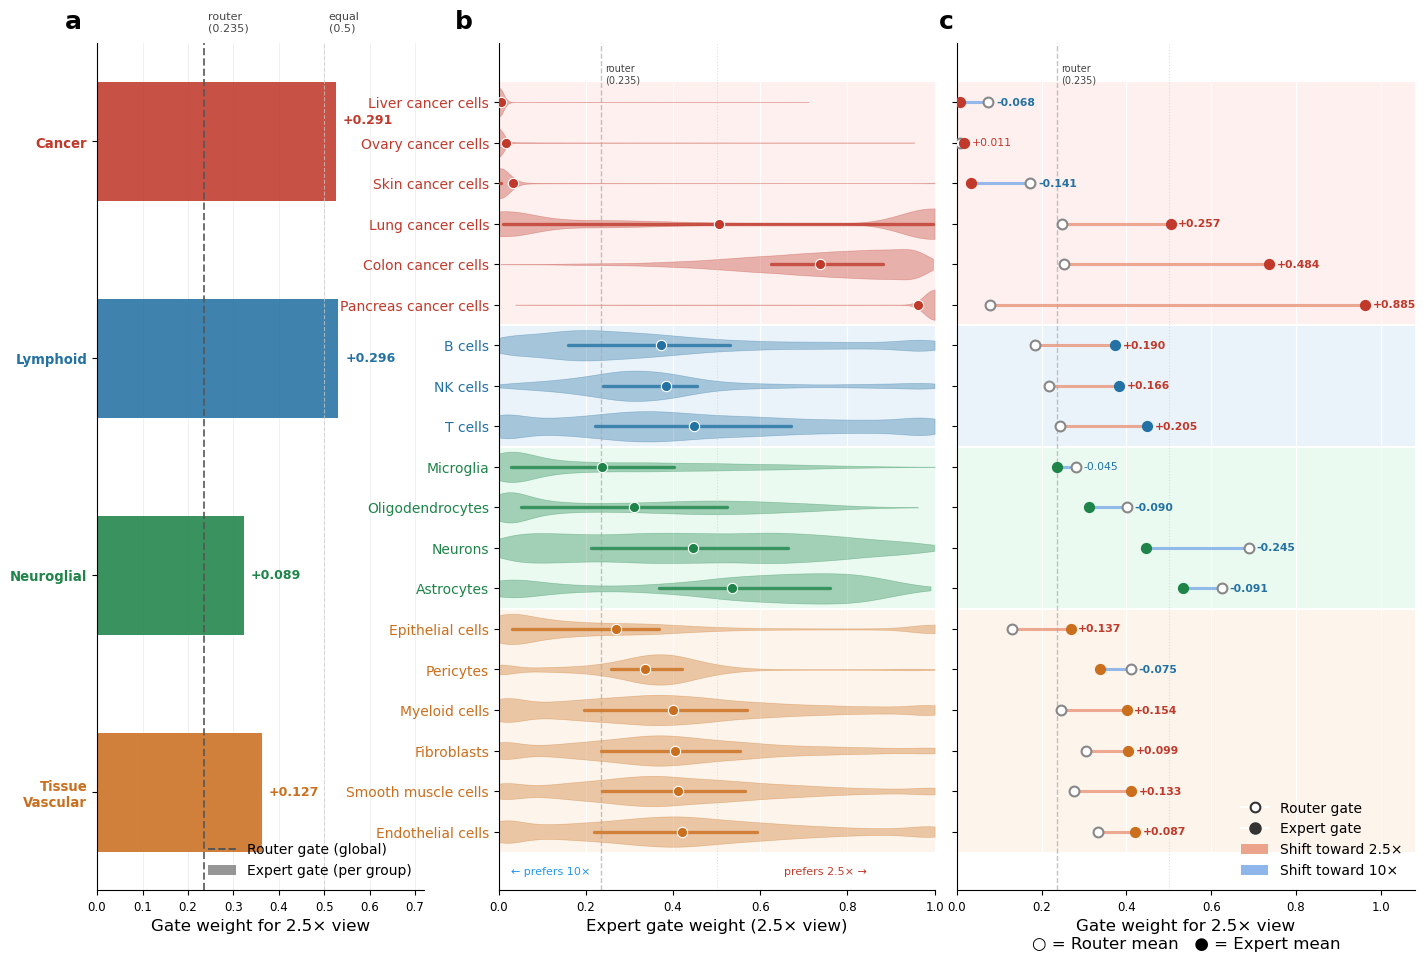

Done.


In [ ]:
#!/usr/bin/env python3
"""
Scale preference panel — v3
============================
Layout:
  Left  (narrow): panel a — coarse bar (Router vs Expert)
  Right (wide):   panel b — violin + dumbbell with shared y-axis

Passthrough classes (Stromal, Stem_Progenitor) excluded from b/c.
Coarse group labels shown as colored background bands on y-axis.

Usage: python scale_preference.py


"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.titlesize":     10,
    "axes.labelsize":     9.5,
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})

# ── Paths ─────────────────────────────────────────────────────────────────
RESULT_DIR = Path(
    "/hpc/group/jilab/rz179/MorphPT_MOE/results/"
    "moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x"
)

# ── Taxonomy ──────────────────────────────────────────────────────────────
FINE_TO_COARSE = {
    "Colon cancer cells":        "Cancer",
    "Liver cancer cells":        "Cancer",
    "Lung cancer cells":         "Cancer",
    "Ovary cancer cells":        "Cancer",
    "Pancreas cancer cells":     "Cancer",
    "Skin cancer cells":         "Cancer",
    "B cells":                   "Lymphoid",
    "NK cells":                  "Lymphoid",
    "T cells":                   "Lymphoid",
    "Astrocytes":                "Neuroglial",
    "Microglia":                 "Neuroglial",
    "Neurons":                   "Neuroglial",
    "Oligodendrocytes":          "Neuroglial",
    "Endothelial cells":         "Tissue_Vascular",
    "Epithelial cells":          "Tissue_Vascular",
    "Fibroblasts":               "Tissue_Vascular",
    "Myeloid cells":             "Tissue_Vascular",
    "Pericytes":                 "Tissue_Vascular",
    "Smooth muscle cells":       "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells":             "Stromal",
}

COARSE_ORDER = [
    "Cancer", "Lymphoid", "Neuroglial", "Tissue_Vascular",
]   # Passthrough excluded

COARSE_COLORS = {
    "Cancer":          "#C0392B",
    "Lymphoid":        "#2471A3",
    "Neuroglial":      "#1E8449",
    "Tissue_Vascular": "#CA6F1E",
}

COARSE_BG = {
    "Cancer":          "#FDF0EF",
    "Lymphoid":        "#EBF3FA",
    "Neuroglial":      "#EAFAF1",
    "Tissue_Vascular": "#FDF5EC",
}

PASSTHROUGH      = {"Stromal", "Stem_Progenitor"}
ROUTER_GATE_2_5X = 0.235

EXPERT_GATE_COARSE = {
    "Cancer":          0.526,
    "Lymphoid":        0.531,
    "Neuroglial":      0.324,
    "Tissue_Vascular": 0.362,
}

# ── Load ──────────────────────────────────────────────────────────────────
print("Loading predictions...")
df = pd.read_parquet(RESULT_DIR / "predictions.parquet")
print(f"  {len(df):,} cells loaded")

# ── Per-fine-class stats (exclude passthrough) ────────────────────────────
fine_stats = []
for cls, coarse in FINE_TO_COARSE.items():
    if coarse in PASSTHROUGH:
        continue
    sub   = df[df["label"] == cls]
    valid = sub["expert_gate_2_5x"].dropna()
    if len(valid) < 20:
        continue
    fine_stats.append({
        "cls":         cls,
        "coarse":      coarse,
        "router_mean": sub["gate_2_5x"].mean(),
        "expert_mean": valid.mean(),
        "expert_vals": valid.values,
        "delta":       valid.mean() - sub["gate_2_5x"].mean(),
    })

df_fine = pd.DataFrame(fine_stats)

# Sort: by coarse group order, within group by expert_mean ascending
coarse_rank = {c: i for i, c in enumerate(COARSE_ORDER)}
df_fine["_cr"] = df_fine["coarse"].map(coarse_rank)
df_fine = df_fine.sort_values(
    ["_cr", "expert_mean"], ascending=[True, True]
).reset_index(drop=True)
df_fine.drop(columns=["_cr"], inplace=True)

n_rows = len(df_fine)

# Coarse group y-ranges
group_ranges = {}
for coarse in COARSE_ORDER:
    idxs = df_fine.index[df_fine["coarse"] == coarse].tolist()
    if idxs:
        group_ranges[coarse] = (min(idxs), max(idxs))

print(f"\n{n_rows} cell types after excluding passthrough")
print(df_fine[["cls", "coarse", "router_mean", "expert_mean", "delta"]].to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════
# Figure layout: left narrow (panel a) + right wide (panels b+c)
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(17, 11))

outer = gridspec.GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1, 2.8],
    wspace=0.12,
)

ax_a = fig.add_subplot(outer[0])

right_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[1],
    wspace=0.05,
    width_ratios=[1, 1.05],
)
ax_b = fig.add_subplot(right_gs[0])
ax_c = fig.add_subplot(right_gs[1], sharey=ax_b)

# Panel labels
for ax, lbl, xoff in zip(
    [ax_a, ax_b, ax_c], ["a", "b", "c"], [-0.10, -0.10, -0.04]
):
    ax.text(xoff, 1.04, lbl, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")


# ═══════════════════════════════════════════════════════════════════════════
# Panel a — Coarse Router vs Expert bar
# ═══════════════════════════════════════════════════════════════════════════
n_groups = len(COARSE_ORDER)
x  = np.arange(n_groups)
bw = 0.55   # wider, now that there's only one bar per row

# Expert bars (centered on each row)
for i, coarse in enumerate(COARSE_ORDER):
    ev    = EXPERT_GATE_COARSE[coarse]
    color = COARSE_COLORS[coarse]
    ax_a.barh(x[i], ev, bw,
              color=color, alpha=0.88, linewidth=0)
    delta = ev - ROUTER_GATE_2_5X
    y_offset = -0.1 if coarse == "Cancer" else 0
    ax_a.text(ev + 0.015, x[i] + y_offset,
              "{:+.3f}".format(delta),
              va="center", fontsize=9,
              color=color, fontweight="bold")

# Reference lines — these now carry the comparison
ax_a.axvline(0.5, color="#CCCCCC", linewidth=0.8,
             linestyle="--", alpha=0.7, zorder=1)
ax_a.axvline(ROUTER_GATE_2_5X, color="#555555", linewidth=1.4,
             linestyle="--", alpha=0.85, zorder=1)

ax_a.set_yticks(x)
ax_a.set_yticklabels([c.replace("_", "\n") for c in COARSE_ORDER],
                      fontsize=9.5)
for tick, coarse in zip(ax_a.get_yticklabels(), COARSE_ORDER):
    tick.set_color(COARSE_COLORS[coarse])
    tick.set_fontweight("bold")

ax_a.set_xlim(0, 0.72)
ax_a.set_xlabel("Gate weight for 2.5× view", fontsize=12)
ax_a.invert_yaxis()

ax_a.grid(axis="x", color="#EEEEEE", linewidth=0.6, zorder=0)
ax_a.set_axisbelow(True)

ax_a.text(0.5 + 0.01, -0.5, "equal\n(0.5)",
          fontsize=8, color="#444444", va="bottom")
ax_a.text(ROUTER_GATE_2_5X + 0.01, -0.5, "router\n(0.235)",
          fontsize=8, color="#444444", va="bottom")

ax_a.legend(handles=[
    mlines.Line2D([0], [0], color="#555555", linestyle="--",
                  linewidth=1.4, label="Router gate (global)"),
    mpatches.Patch(facecolor="#888888", alpha=0.88,
                   label="Expert gate (per group)"),
], fontsize=10, loc="lower right", frameon=False)


# ═══════════════════════════════════════════════════════════════════════════
# Shared background bands for coarse groups (drawn on both b and c)
# ═══════════════════════════════════════════════════════════════════════════
def draw_group_bands(ax):
    for coarse, (i_start, i_end) in group_ranges.items():
        ax.axhspan(i_start - 0.5, i_end + 0.5,
                   facecolor=COARSE_BG[coarse], alpha=1.0, zorder=0)
        # Separator line between groups
        if i_end < n_rows - 1:
            ax.axhline(i_end + 0.5, color="white",
                       linewidth=1.5, zorder=1)

    # Coarse group labels on left of ax_b only (handled separately)


# ═══════════════════════════════════════════════════════════════════════════
# Panel b — Violin
# ═══════════════════════════════════════════════════════════════════════════
draw_group_bands(ax_b)

ax_b.axvline(ROUTER_GATE_2_5X, color="#AAAAAA", linewidth=1.0,
             linestyle="--", alpha=0.7, zorder=2)
ax_b.axvline(0.5, color="#CCCCCC", linewidth=0.8,
             linestyle=":", alpha=0.6, zorder=2)

for i, row in df_fine.iterrows():
    color = COARSE_COLORS[row["coarse"]]
    vals  = row["expert_vals"]

    # Violin
    parts = ax_b.violinplot(
        [vals], positions=[i], vert=False,
        widths=0.75, showmedians=False, showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.35)
        pc.set_edgecolor(color)
        pc.set_linewidth(0.5)

    # IQR
    q25, q75 = np.percentile(vals, [25, 75])
    ax_b.plot([q25, q75], [i, i], color=color,
              linewidth=2.4, alpha=0.8, zorder=3,
              solid_capstyle="round")

    # Mean dot
    ax_b.scatter(row["expert_mean"], i, color=color,
                 s=55, zorder=4, edgecolors="white", linewidths=0.8)



ax_b.set_yticks(range(n_rows))
ax_b.set_yticklabels(df_fine["cls"].tolist(), fontsize=10)
for tick, (_, row) in zip(ax_b.get_yticklabels(), df_fine.iterrows()):
    tick.set_color(COARSE_COLORS[row["coarse"]])
ax_b.invert_yaxis()

ax_b.set_xlim(0.0, 1.0)
ax_b.set_xlabel("Expert gate weight (2.5× view)", fontsize=12)
#ax_b.set_title(
#    "Expert gate distribution per cell type\n"
 ##   "● mean  |  bar = IQR  |  shape = distribution",
 #   fontsize=10, pad=8, loc="left",
#)
ax_b.grid(axis="x", color="white", linewidth=0.8, zorder=1)
ax_b.set_axisbelow(True)

ax_b.text(0.12, n_rows + 0.1, "← prefers 10×",
          fontsize=8, color="#2196F3", ha="center", va="bottom")
ax_b.text(0.75, n_rows + 0.1, "prefers 2.5× →",
          fontsize=8, color="#C0392B", ha="center", va="bottom")
ax_b.text(ROUTER_GATE_2_5X + 0.01, -0.95, "router\n(0.235)",
          fontsize=7, color="#444444", va="top")

# ═══════════════════════════════════════════════════════════════════════════
# Panel c — Dumbbell shift
# ═══════════════════════════════════════════════════════════════════════════
draw_group_bands(ax_c)

ax_c.axvline(ROUTER_GATE_2_5X, color="#AAAAAA", linewidth=1.0,
             linestyle="--", alpha=0.7, zorder=2)
ax_c.axvline(0.5, color="#CCCCCC", linewidth=0.8,
             linestyle=":", alpha=0.6, zorder=2)
             
for i, row in df_fine.iterrows():
    color = COARSE_COLORS[row["coarse"]]
    r_val = row["router_mean"]
    e_val = row["expert_mean"]
    delta = row["delta"]

    lo = min(r_val, e_val)
    hi = max(r_val, e_val)

    # Line color: warm = shift toward 2.5x, cool = shift toward 10x
    lc = "#E8957A" if delta > 0 else "#7AAAE8"
    ax_c.plot([lo, hi], [i, i], color=lc,
              linewidth=2.2, alpha=0.8, zorder=2,
              solid_capstyle="round")

    # Router dot
    ax_c.scatter(r_val, i, s=50, zorder=3,
                 facecolors="white", edgecolors="#888888",
                 linewidths=1.5)

    # Expert dot
    ax_c.scatter(e_val, i, s=50, zorder=3,
                 facecolors=color, edgecolors=color)

    # Delta label
    sign = "+" if delta >= 0 else ""
    ax_c.text(hi + 0.018, i,
              "{}{:.3f}".format(sign, delta),
              va="center", ha="left", fontsize=7.8,
              color="#C0392B" if delta > 0 else "#2471A3",
              fontweight="bold" if abs(delta) > 0.05 else "normal")

plt.setp(ax_c.get_yticklabels(), visible=False)

ax_c.set_xlim(0.0, 1.08)
ax_c.set_xlabel(
    "Gate weight for 2.5× view\n"
    "○ = Router mean   ● = Expert mean",
    fontsize=12,
)
#ax_c.set_title(
#    "Scale shift: Router → Expert\n"
#    "Warm = toward 2.5×   Cool = toward 10×",
#    fontsize=10, pad=8, loc="left",
#)
ax_c.grid(axis="x", color="white", linewidth=0.8, zorder=1)
ax_c.set_axisbelow(True)

ax_c.text(ROUTER_GATE_2_5X + 0.01, -0.95, "router\n(0.235)",
          fontsize=7, color="#444444", va="top")

ax_c.legend(handles=[
    mlines.Line2D([0], [0], marker="o", color="w",
                  markerfacecolor="white", markeredgecolor="#333333",
                  markersize=7, markeredgewidth=1.5,
                  label="Router gate"),
    mlines.Line2D([0], [0], marker="o", color="w",
                  markerfacecolor="#333333", markeredgecolor="#333333",
                  markersize=8, label="Expert gate"),
    mpatches.Patch(facecolor="#E8957A", alpha=0.85,
                   label="Shift toward 2.5×"),
    mpatches.Patch(facecolor="#7AAAE8", alpha=0.85,
                   label="Shift toward 10×"),
], fontsize=10, loc="lower right", frameon=False)


# ── Save ──────────────────────────────────────────────────────────────────
for ext in ("pdf", "png"):
    dpi = 300 if ext == "pdf" else 150
    fig.savefig("fig_scale_panel.{}".format(ext), format=ext,
                dpi=dpi, bbox_inches="tight")
    print("Saved: fig_scale_panel.{}".format(ext))

plt.show()
print("Done.")

## 总图

In [ ]:
#!/usr/bin/env python3
"""
Combined panel figure — 3 rows
================================
Row 1 — Confusion (2 cols):
  Left col (stacked): a = coarse CM (top), c = coarse bar (bottom)
  Right col (full):   b = 21×21 fine CM

Row 2 — Performance (3 cols):
  d = combined F1 + BalAcc bar
  e = per-class F1 dumbbell
  f = per-class Accuracy dumbbell

Row 3 — Confidence (2 cols):
  g = joint confidence bucket bar chart
  h = performance vs threshold sweep

Usage: python fig_combined.py
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     0.8,
    "axes.titlesize":     10,
    "axes.labelsize":     10,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
})

# ── Paths ─────────────────────────────────────────────────────────────────
BASE       = Path("/hpc/group/jilab/rz179/MorphPT_MOE/experiments")
MOE_RESULT = Path(
    "/hpc/group/jilab/rz179/MorphPT_MOE/results/"
    "moe_e2e_nobreast_6clusters_filtered_v3_with_expert_margin_with_gate_2_5x"
)

MODEL_PATHS = {
    "ResNet-50":    BASE / "baseline_resnet50_freeze_2p5x"                  / "per_class.json",
    "Swin-B":       BASE / "baseline_swin_base_patch4_window7_224_2p5x"     / "per_class.json",
    "DINOv3": BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_2p5x" / "per_class.json",
    "MorphPT":  MOE_RESULT / "per_class_soft.json",
}

MODEL_COLORS = {
    "ResNet-50":    "#E08430",   # orange — distinct from Stromal gray
    "Swin-B":       "#2CA02C",   # green
    "DINOv3":       "#378ADD",   # blue
    "MorphPT":      "#E24B4A",   # red 
}

MOE_KEY  = "MorphPT"
BL_EDGE  = "#666666"
LINE_COL = "#BBBBBB"

MARGIN_COL = "router_x_maxpe"
PRED_COL   = "pred_soft"
N_STEPS    = 200

# Confidence colors
C_BAL = "#378ADD"
C_F1  = "#1D9E75"
C_ACC = "#E24B4A"
C_BAR = "#B5D4F4"
C_THR = "#D4700A"

# ── Taxonomy ──────────────────────────────────────────────────────────────
FINE_TO_COARSE = {
    "Colon cancer cells":        "Cancer",
    "Liver cancer cells":        "Cancer",
    "Lung cancer cells":         "Cancer",
    "Ovary cancer cells":        "Cancer",
    "Pancreas cancer cells":     "Cancer",
    "Skin cancer cells":         "Cancer",
    "B cells":                   "Lymphoid",
    "NK cells":                  "Lymphoid",
    "T cells":                   "Lymphoid",
    "Astrocytes":                "Neuroglial",
    "Microglia":                 "Neuroglial",
    "Neurons":                   "Neuroglial",
    "Oligodendrocytes":          "Neuroglial",
    "Endothelial cells":         "Tissue_Vascular",
    "Epithelial cells":          "Tissue_Vascular",
    "Fibroblasts":               "Tissue_Vascular",
    "Myeloid cells":             "Tissue_Vascular",
    "Pericytes":                 "Tissue_Vascular",
    "Smooth muscle cells":       "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells":             "Stromal",
}

COARSE_ORDER = [
    "Cancer", "Lymphoid", "Neuroglial",
    "Stem_Progenitor", "Stromal", "Tissue_Vascular",
]

COARSE_COLORS = {
    "Cancer":          "#C0392B",
    "Lymphoid":        "#2471A3",
    "Neuroglial":      "#1E8449",
    "Tissue_Vascular": "#CA6F1E",
    "Stem_Progenitor": "#6C3483",
    "Stromal":         "#717D7E",
}

OVERALL_ROUTER_BAL = 0.80
OVERALL_E2E_MF1    = 0.6109
OVERALL_E2E_BAL    = 0.6294


# ═══════════════════════════════════════════════════════════════════════════
# Load all data
# ═══════════════════════════════════════════════════════════════════════════
def load_per_class(path):
    rows = json.loads(Path(path).read_text())
    return {r["class"]: r for r in rows}

print("Loading performance data...")
RESULTS = {}
for model, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f"  WARNING: {p} not found")
        continue
    RESULTS[model] = load_per_class(p)
    print(f"  Loaded {model}: {len(RESULTS[model])} classes")

models      = list(RESULTS.keys())
bl_models   = [m for m in models if m != MOE_KEY]
all_classes = sorted(RESULTS[models[0]].keys())

def get_metric(model, cls, metric):
    return RESULTS.get(model, {}).get(cls, {}).get(metric, 0.0)

def global_mean(model, metric):
    vals = [get_metric(model, c, metric) for c in all_classes
            if get_metric(model, c, "n") > 0]
    return float(np.mean(vals)) if vals else 0.0

def global_acc(model):
    total_n  = sum(get_metric(model, c, "n") for c in all_classes)
    total_tp = sum(
        round(get_metric(model, c, "rec") * get_metric(model, c, "n"))
        for c in all_classes
    )
    return total_tp / total_n if total_n > 0 else 0.0

print("Loading confusion data...")
cm_json     = json.loads((MOE_RESULT / "confusion_matrix_soft.json").read_text())
json_names  = cm_json["class_names"]
cm21_raw    = np.array(cm_json["matrix"], dtype=np.int64)
json_to_idx = {c: i for i, c in enumerate(json_names)}

sorted_fine = []
for coarse in COARSE_ORDER:
    sorted_fine += sorted(c for c in json_names
                          if FINE_TO_COARSE.get(c) == coarse)

sort_idx  = [json_to_idx[c] for c in sorted_fine]
cm21_sort = cm21_raw[np.ix_(sort_idx, sort_idx)]
cm21_pct  = 100 * cm21_sort / cm21_sort.sum(axis=1, keepdims=True).clip(min=1)
n_fine    = len(sorted_fine)

boundaries = []
pos = 0
for coarse in COARSE_ORDER:
    pos += sum(1 for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse)
    boundaries.append(pos)

print("Loading predictions parquet...")
df        = pd.read_parquet(MOE_RESULT / "predictions.parquet")
n_coarse  = len(COARSE_ORDER)
c_to_idx  = {c: i for i, c in enumerate(COARSE_ORDER)}

cm6 = np.zeros((n_coarse, n_coarse), dtype=np.int64)
for t, p in zip(df["coarse_label"].values, df["router_pred"].values):
    ti, pi = c_to_idx.get(t, -1), c_to_idx.get(p, -1)
    if ti >= 0 and pi >= 0:
        cm6[ti, pi] += 1
cm6_pct = 100 * cm6 / cm6.sum(axis=1, keepdims=True).clip(min=1)

pc_rows    = json.loads((MOE_RESULT / "per_class_soft.json").read_text())
pc_by_name = {r["class"]: r for r in pc_rows}

coarse_rows = []
for coarse in COARSE_ORDER:
    fines   = [c for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse]
    f1s     = [pc_by_name[c]["f1"]  for c in fines if c in pc_by_name]
    recs    = [pc_by_name[c]["rec"] for c in fines if c in pc_by_name]
    n_cells = int(sum(pc_by_name[c].get("n", 0) for c in fines if c in pc_by_name))
    # accuracy = weighted sum of per-class recall (tp/total_n)
    total_tp = sum(
        round(pc_by_name[c]["rec"] * pc_by_name[c]["n"])
        for c in fines if c in pc_by_name
    )
    acc_val = total_tp / n_cells if n_cells > 0 else 0.0
    coarse_rows.append({
        "coarse":   coarse,
        "n_cells":  n_cells,
        "macro_f1": round(float(np.mean(f1s)),  4) if f1s  else 0.0,
        "bal_acc":  round(float(np.mean(recs)), 4) if recs else 0.0,
        "acc":      round(acc_val, 4),
    })
df_coarse = pd.DataFrame(coarse_rows)

print(df.columns.tolist())


# ── Oracle per-class metrics (parsed from inference log) ──────────────────
ORACLE_PER_CLASS = {
    "Stem and progenitor cells": {"prec": 1.000, "rec": 1.000, "f1": 1.000, "n": 10000},
    "Stromal cells":              {"prec": 1.000, "rec": 1.000, "f1": 1.000, "n":  4573},
    "Colon cancer cells":         {"prec": 0.999, "rec": 1.000, "f1": 1.000, "n": 10000},
    "Pancreas cancer cells":      {"prec": 0.999, "rec": 1.000, "f1": 1.000, "n":  8568},
    "Liver cancer cells":         {"prec": 1.000, "rec": 0.999, "f1": 0.999, "n":  2214},
    "Skin cancer cells":          {"prec": 0.999, "rec": 0.999, "f1": 0.999, "n": 10000},
    "Ovary cancer cells":         {"prec": 1.000, "rec": 0.993, "f1": 0.996, "n": 10000},
    "Lung cancer cells":          {"prec": 0.992, "rec": 0.999, "f1": 0.996, "n": 10000},
    "Oligodendrocytes":           {"prec": 0.841, "rec": 0.823, "f1": 0.832, "n": 10000},
    "Neurons":                    {"prec": 0.769, "rec": 0.791, "f1": 0.780, "n":  3135},
    "Epithelial cells":           {"prec": 0.604, "rec": 0.687, "f1": 0.643, "n": 10000},
    "T cells":                    {"prec": 0.524, "rec": 0.764, "f1": 0.621, "n": 10000},
    "B cells":                    {"prec": 0.653, "rec": 0.592, "f1": 0.621, "n": 10000},
    "NK cells":                   {"prec": 0.793, "rec": 0.502, "f1": 0.615, "n": 10000},
    "Microglia":                  {"prec": 0.561, "rec": 0.591, "f1": 0.576, "n":  2583},
    "Pericytes":                  {"prec": 0.615, "rec": 0.488, "f1": 0.544, "n":  4120},
    "Astrocytes":                 {"prec": 0.535, "rec": 0.532, "f1": 0.533, "n":  2208},
    "Endothelial cells":          {"prec": 0.514, "rec": 0.507, "f1": 0.511, "n": 10000},
    "Myeloid cells":              {"prec": 0.536, "rec": 0.464, "f1": 0.497, "n": 10000},
    "Smooth muscle cells":        {"prec": 0.487, "rec": 0.465, "f1": 0.476, "n": 10000},
    "Fibroblasts":                {"prec": 0.416, "rec": 0.474, "f1": 0.443, "n": 10000},
}

# Aggregate Oracle by coarse group (mirrors df_coarse construction)
oracle_rows = []
for coarse in COARSE_ORDER:
    fines = [c for c in sorted_fine if FINE_TO_COARSE.get(c) == coarse]
    f1s      = [ORACLE_PER_CLASS[c]["f1"]  for c in fines]
    recs     = [ORACLE_PER_CLASS[c]["rec"] for c in fines]
    n_cells  = sum(ORACLE_PER_CLASS[c]["n"] for c in fines)
    total_tp = sum(round(ORACLE_PER_CLASS[c]["rec"] * ORACLE_PER_CLASS[c]["n"])
                   for c in fines)
    acc_val  = total_tp / n_cells if n_cells > 0 else 0.0
    oracle_rows.append({
        "coarse":   coarse,
        "macro_f1": round(float(np.mean(f1s)), 4),
        "acc":      round(acc_val, 4),
    })
df_oracle = pd.DataFrame(oracle_rows)
print("Oracle per-coarse:\n", df_oracle)




# Confidence metrics
all_cls_conf = sorted(df["label"].unique())
N            = len(df)

def compute_conf_metrics(y_true, y_pred):
    n2i = {n: i for i, n in enumerate(all_cls_conf)}
    ti  = np.array([n2i.get(y, -1) for y in y_true])
    pi  = np.array([n2i.get(y, -1) for y in y_pred])
    rows = []
    for i in range(len(all_cls_conf)):
        tp = int(((ti==i)&(pi==i)).sum())
        fn = int(((ti==i)&(pi!=i)).sum())
        fp = int(((ti!=i)&(pi==i)).sum())
        n  = tp + fn
        if n == 0: continue
        prec = tp / max(tp+fp, 1)
        rec  = tp / max(tp+fn, 1)
        f1   = 2*prec*rec / max(prec+rec, 1e-12)
        rows.append({"rec": rec, "f1": f1})
    bal = float(np.mean([r["rec"] for r in rows]))
    mf1 = float(np.mean([r["f1"]  for r in rows]))
    acc = float((ti==pi).sum()) / max(len(ti), 1)
    return bal, mf1, acc

base_bal, base_mf1, base_acc = compute_conf_metrics(
    df["label"].values, df[PRED_COL].values
)

# Bucket data
buckets = [(i/10, (i+1)/10) for i in range(10)]
bin_labels, cells, baccs, macros, accs = [], [], [], [], []
for lo, hi in buckets:
    mask   = (df[MARGIN_COL] >= lo) & (df[MARGIN_COL] < hi)
    subset = df[mask]
    if len(subset) == 0: continue
    bal, mf1, acc = compute_conf_metrics(
        subset["label"].values, subset[PRED_COL].values)
    bin_labels.append("{:.1f}-{:.1f}".format(lo, hi))
    cells.append(len(subset))
    baccs.append(bal); macros.append(mf1); accs.append(acc)

# Discrete threshold sweep
thresholds_disc = np.arange(0.0, 1.0, 0.1)
disc_thr, disc_bal, disc_f1, disc_acc, disc_cov = [], [], [], [], []
for t in thresholds_disc:
    subset = df[df[MARGIN_COL] >= t]
    if len(subset) < 50: break
    bal, mf1, acc = compute_conf_metrics(
        subset["label"].values, subset[PRED_COL].values)
    disc_thr.append(t); disc_bal.append(bal)
    disc_f1.append(mf1); disc_acc.append(acc)
    disc_cov.append(100 * len(subset) / N)
disc_thr = np.array(disc_thr); disc_bal = np.array(disc_bal)
disc_f1  = np.array(disc_f1);  disc_acc = np.array(disc_acc)
disc_cov = np.array(disc_cov)

print("All data loaded.")



Loading performance data...
  Loaded ResNet-50: 21 classes
  Loaded Swin-B: 21 classes
  Loaded DINOv3: 21 classes
  Loaded MorphPT: 21 classes
Loading confusion data...
Loading predictions parquet...


['cell_id', 'label', 'coarse_label', 'tissue', 'x_centroid', 'y_centroid', 'patch_id', 'img_path_2p5x', 'img_path_10x', 'router_pred', 'router_margin', 'gate_2_5x', 'gate_10x', 'pred_top1', 'pred_top3', 'pred_soft', 'expert_margin', 'expert_top1_prob', 'expert_gate_2_5x', 'router_x_expert', 'router_x_maxpe']
Oracle per-coarse:
             coarse  macro_f1     acc
0           Cancer    0.9983  0.9982
1         Lymphoid    0.6190  0.6193
2       Neuroglial    0.6803  0.7482
3  Stem_Progenitor    1.0000  1.0000
4          Stromal    1.0000  1.0000
5  Tissue_Vascular    0.5190  0.5170
All data loaded.


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# Figure layout
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(26, 28))

outer = gridspec.GridSpec(
    3, 1,
    figure=fig,
    height_ratios=[2, 1.2, 1.2],
    hspace=0.6,
)

# ── Row 1: confusion ──────────────────────────────────────────────────────
row1 = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[0],
    width_ratios=[1, 1.8],
    wspace=0.22,
)

# Left col: a (coarse CM) + c (coarse bar) stacked
left_gs = gridspec.GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=row1[0],
    hspace=0.52,
    height_ratios=[1.05, 0.95],
)
ax_a = fig.add_subplot(left_gs[0])   # a: coarse CM
ax_c = fig.add_subplot(left_gs[1])   # c: coarse bar

# Right col: b (fine CM, large)
ax_b = fig.add_subplot(row1[1])      # b: 21×21 fine CM

# ── Row 2: performance ────────────────────────────────────────────────────

row2 = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=outer[1],
    width_ratios=[1.8, 1.2, 1.2],
    wspace=0.08,
)

ax_d = fig.add_subplot(row2[0])   # d: combined bar
ax_e = fig.add_subplot(row2[1])   # e: F1 dumbbell
ax_f = fig.add_subplot(row2[2])   # f: Acc dumbbell

# ── Row 3: confidence ─────────────────────────────────────────────────────
row3 = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[2],
    width_ratios=[1, 1.6],
    wspace=0.1,
)
ax_g = fig.add_subplot(row3[0])   # g: bucket bar
ax_h = fig.add_subplot(row3[1])   # h: threshold sweep


# ═══════════════════════════════════════════════════════════════════════════
# Panel a — 6×6 coarse routing confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
im6 = ax_a.imshow(cm6_pct, cmap="Blues", vmin=0, vmax=100,
                  aspect="equal", interpolation="nearest")
cb6 = plt.colorbar(im6, ax=ax_a, fraction=0.046, pad=0.04, shrink=0.85,anchor=(0.0, -0.3))
cb6.set_label("% of true cluster", fontsize=24, labelpad=4)
cb6.ax.tick_params(labelsize=18, length=2)
cb6.outline.set_linewidth(0.5)

clabels = [c.replace("_", "\n") for c in COARSE_ORDER]
ax_a.set_xticks(range(n_coarse))
ax_a.set_yticks(range(n_coarse))
ax_a.set_xticklabels(clabels, rotation=45, ha="right", fontsize=14)
ax_a.set_yticklabels(clabels, fontsize=18)

for i in range(n_coarse):
    for j in range(n_coarse):
        v = cm6_pct[i, j]
        ax_a.text(j, i, "{:.1f}".format(v),
                  ha="center", va="center", fontsize=14,
                  color="white" if v > 55 else "#333333")
for k in range(n_coarse):
    ax_a.add_patch(plt.Rectangle(
        (k-0.5, k-0.5), 1, 1,
        fill=False, edgecolor="#C0392B", linewidth=1.8, zorder=3))

for spine in ax_a.spines.values(): spine.set_visible(False)
ax_a.tick_params(length=0)
ax_a.set_xlabel("Predicted Cluster", fontsize=24, labelpad=5)
ax_a.set_ylabel("True Cluster", fontsize=24, labelpad=5)
#ax_a.set_title("Coarse routing confusion matrix (row %)\n",fontsize=10, pad=6, loc="left")


# ═══════════════════════════════════════════════════════════════════════════
# Panel b — 21×21 fine confusion matrix
# ═══════════════════════════════════════════════════════════════════════════
im21 = ax_b.imshow(cm21_pct, cmap="Blues", vmin=0, vmax=100,
                   aspect="equal", interpolation="nearest")
cb21 = plt.colorbar(im21, ax=ax_b, fraction=0.020, pad=0.02, shrink=0.85)
cb21.set_label("% of true class", fontsize=24, labelpad=4)
cb21.ax.tick_params(labelsize=14, length=2)
cb21.outline.set_linewidth(0.5)

short_labels = [c.replace(" cells", "").replace(" cancer cells", "\ncancer")
                for c in sorted_fine]
ax_b.set_xticks(range(n_fine))
ax_b.set_yticks(range(n_fine))
ax_b.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=16)
ax_b.set_yticklabels(short_labels, fontsize=16)

for i in range(n_fine):
    for j in range(n_fine):
        v = cm21_pct[i, j]
        if v > 5:
            ax_b.text(j, i, "{:.0f}".format(v),
                      ha="center", va="center", fontsize=16,
                      color="white" if v > 55 else "#333333")

for b in boundaries[:-1]:
    ax_b.axhline(b-0.5, color="#C0392B", linewidth=1.0, alpha=0.6)
    ax_b.axvline(b-0.5, color="#C0392B", linewidth=1.0, alpha=0.6)

for spine in ax_b.spines.values(): spine.set_visible(False)
ax_b.tick_params(length=0)
ax_b.set_xlabel("Predicted class", fontsize=24, labelpad=6)
ax_b.set_ylabel("True class", fontsize=24, labelpad=6)
#ax_b.set_title("Fine-class confusion matrix (row %)", fontsize=10,pad=8, loc="left")


# ═══════════════════════════════════════════════════════════════════════════
# Panel c — Coarse-group bar chart
# ═══════════════════════════════════════════════════════════════════════════
x_pos  = np.arange(n_coarse)
width  = 0.35
colors = [COARSE_COLORS[c] for c in COARSE_ORDER]

overall_coarse_f1  = global_mean(MOE_KEY, "f1")
overall_coarse_acc = global_acc(MOE_KEY)


bars_f1  = ax_c.bar(x_pos - width/2 , df_coarse["macro_f1"], width,
                    color=colors, alpha=0.85, linewidth=0.8,
                    hatch="///", edgecolor="white", label="Macro F1")
bars_bal = ax_c.bar(x_pos + width/2 , df_coarse["acc"], width,
                    color=colors,
                    alpha=1.0, linewidth=0, label="Accuracy")

# ── Oracle markers and routing-gap lines ──────────────────────────────────
# Passthrough groups have no expert model — Oracle is trivially 1.0,
# so skip both Oracle markers for them.
PASSTHROUGH = {"Stromal", "Stem_Progenitor"}
for i, coarse in enumerate(COARSE_ORDER):
    if coarse in PASSTHROUGH:
        continue
    color = COARSE_COLORS[coarse]
    f1_actual = df_coarse.loc[df_coarse["coarse"] == coarse, "macro_f1"].values[0]
    f1_oracle = df_oracle.loc[df_oracle["coarse"] == coarse, "macro_f1"].values[0]
    x_marker  = i - width/2   # center on the F1 (hatched) bar

    # Dotted gap line from F1 bar top up to Oracle marker
    if f1_oracle > f1_actual + 0.005:
        ax_c.plot([x_marker, x_marker],
                  [f1_actual, f1_oracle],
                  color="#666666", linewidth=2.5, linestyle=(0, (1, 1.5)),
                  alpha=0.75, zorder=2)

    # Hollow circle at Oracle F1
    ax_c.scatter([x_marker], [f1_oracle],
                 s=120, marker="*",
                 facecolors="white", edgecolors=color,
                 linewidths=1.8, zorder=5)

    # --- Accuracy Oracle star (on the solid Accuracy bar) ---
    row_actual = df_coarse.loc[df_coarse["coarse"] == coarse]
    row_oracle = df_oracle.loc[df_oracle["coarse"] == coarse]

    acc_actual = row_actual["acc"].values[0]
    acc_oracle = row_oracle["acc"].values[0]
    x_acc = i + width/2
    if acc_oracle > acc_actual + 0.005:
        ax_c.plot([x_acc, x_acc], [acc_actual, acc_oracle],
                  color="#666666", linewidth=2.5, linestyle=(0, (1, 1.5)),
                  alpha=0.75, zorder=2)
    ax_c.scatter([x_acc], [acc_oracle],
                 s=120, marker="*",
                 facecolors="white", edgecolors=color,
                 linewidths=1.8, zorder=5)

    # +Δ gap label, only when meaningful
    #gap = f1_oracle - f1_actual
    #if gap > 0.03:
        #ax_c.text(x_marker,f1_oracle + 0.03,
                 # "+{:.2f}".format(gap),
                 # ha="center", va="bottom", fontsize=10,
                 # color="#555555", style="italic")


for bar, coarse in zip(bars_f1, COARSE_ORDER):
    h = bar.get_height()
    x_text = bar.get_x() - 0.04 + bar.get_width()/2
    y_text = h + 0.013
    if coarse == "Neuroglial":
        x_text = bar.get_x() - 0.1
    ax_c.text(x_text, y_text,
              "{:.2f}".format(h),
              ha="center", va="bottom", fontsize=14, color="black")

for bar, coarse in zip(bars_bal, COARSE_ORDER):
    h = bar.get_height()
    x_text = bar.get_x() + 0.02 + bar.get_width()/2
    y_text = h + 0.013
    if coarse == "Neuroglial" or coarse == "Cancer":
        y_text = h + 0.06
    ax_c.text(x_text, y_text,
              "{:.2f}".format(h),
              ha="center", va="bottom", fontsize=14, color="black")

ax_c.axhline(overall_coarse_f1, color="#555555", linestyle="--",
             linewidth=1, alpha=0.7)
ax_c.axhline(overall_coarse_acc, color="#555555", linestyle=":",
             linewidth=1, alpha=0.7)

bar_xlabels = [
    "{}\n({:,})".format(r["coarse"].replace("_", "\n"), r["n_cells"])
    for _, r in df_coarse.iterrows()
]
ax_c.set_xticks(x_pos)
ax_c.set_xticklabels(bar_xlabels, fontsize=16)
for tick, coarse in zip(ax_c.get_xticklabels(), COARSE_ORDER):
    tick.set_color(COARSE_COLORS[coarse])

# put F1 label above, Acc label below its line
ax_c.text(n_coarse + 0.15, overall_coarse_f1 + 0.015, 
          "Avg F1: {:.2f}".format(overall_coarse_f1),
          ha="right", va="bottom", fontsize=12, color="#333333")

ax_c.text(n_coarse + 0.15, overall_coarse_acc - 0.015,
          "Avg Acc: {:.2f}".format(overall_coarse_acc),
          ha="right", va="top", fontsize=12, color="#333333")


ax_c.set_ylim(0, 1.12)
ax_c.set_ylabel("Score", fontsize=24)
ax_c.tick_params(axis="y", labelsize=12)
#ax_c.set_title("End-to-end performance by coarse group", fontsize=10, pad=6, loc="left")
ax_c.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax_c.grid(axis="y", color="#DDDDDD", linewidth=0.6, zorder=0)
ax_c.set_axisbelow(True)

ax_c.legend(handles=[
    mpatches.Patch(facecolor="#888888", hatch="///", edgecolor="white", label="Macro F1"),
    mpatches.Patch(facecolor="#888888", label="Accuracy"),
    mlines.Line2D([0], [0], marker="*", color="w",
                  markerfacecolor="white", markeredgecolor="#444444",
                  markersize=10, markeredgewidth=1.8,
                  label="Oracle (F1 / Acc)"),
], fontsize=18, loc="upper right", bbox_to_anchor=(1.20, 1.18),
   frameon=False, handlelength=1.4)

# ═══════════════════════════════════════════════════════════════════════════
# Panel d — Combined F1 + Acc bar
# ═══════════════════════════════════════════════════════════════════════════
f1_vals  = [global_mean(m, "f1") for m in models]
acc_vals = [global_acc(m)        for m in models]
xs = np.arange(len(models))
bw = 0.32

for i, m in enumerate(models):
    color = MODEL_COLORS[m]
    #ax_d.bar(xs[i] - bw/2, f1_vals[i], bw,
             #color=color, alpha=1.0 if m == MOE_KEY else 0.80,
            # edgecolor="white", linewidth=0.5)
    #ax_d.bar(xs[i] + bw/2, acc_vals[i], bw,
             #color=color, alpha=0.45 if m == MOE_KEY else 0.35,
             #edgecolor="white", linewidth=0.5)


    ax_d.bar(xs[i] - bw/2, f1_vals[i], bw,
         color=color, alpha=0.85, linewidth=0.8,
         hatch="///", edgecolor="white")
    ax_d.bar(xs[i] + bw/2, acc_vals[i], bw,
         color=color, alpha=1.0, linewidth=0)
    ax_d.text(xs[i] - bw/2 - 0.035, f1_vals[i] + 0.005,
              "{:.2f}".format(f1_vals[i]),
              ha="center", va="bottom", fontsize=14,
              color=color if m == MOE_KEY else "#222222",
              fontweight="bold" if m == MOE_KEY else "normal")
    ax_d.text(xs[i] + bw/2 + 0.025, acc_vals[i] + (0.02 if m == MOE_KEY else 0.005),
              "{:.2f}".format(acc_vals[i]),
              ha="center", va="bottom", fontsize=14,
              color=color if m == MOE_KEY else "#222222",
              fontweight="bold" if m == MOE_KEY else "normal")

moe_i    = models.index(MOE_KEY)
best_f1  = max(global_mean(m, "f1") for m in bl_models)
best_acc = max(global_acc(m)        for m in bl_models)
moe_f1   = global_mean(MOE_KEY, "f1")
moe_acc  = global_acc(MOE_KEY)

# +Δ labels to the right of MorphPT bars
#ax_d.text(moe_i + bw + 0.10, moe_f1, "{:+.3f}".format(moe_f1 - best_f1), va="center", ha="left", fontsize=8.5, color="#E24B4A", fontweight="bold")
#ax_d.text(moe_i + bw + 0.10, moe_acc, "{:+.3f}".format(moe_acc - best_acc), va="center", ha="left", fontsize=8.5, color="#E24B4A", fontweight="bold")

ax_d.set_xticks(xs)
ax_d.set_xticklabels(models, fontsize=18, ha="center")
ax_d.get_xticklabels()[moe_i].set_color("#E24B4A")
ax_d.get_xticklabels()[moe_i].set_fontweight("bold")

y_floor = min(f1_vals + acc_vals) - 0.06
ax_d.set_ylim(max(0, y_floor), min(1.0, max(f1_vals + acc_vals) + 0.12))
ax_d.set_xlim(-0.6, len(models) + 0.2)
ax_d.set_ylabel("Score", fontsize=24)

ax_d.tick_params(axis="y", labelsize=14)
#ax_d.set_title("Overall performance by fine classes", fontsize=10, pad=8, loc="left")
ax_d.grid(axis="y", color="#EEEEEE", linewidth=0.6, zorder=0)
ax_d.set_axisbelow(True)
#ax_d.legend(handles=[
#    mpatches.Patch(facecolor="#888888", alpha=1.0,  label="Macro F1"),
#    mpatches.Patch(facecolor="#888888", alpha=0.40, label="Accuracy"),
#], fontsize=12, loc="upper left", frameon=False)

ax_d.legend(handles=[
    mpatches.Patch(facecolor="#888888", hatch="///", edgecolor="white", label="Macro F1"),
    mpatches.Patch(facecolor="#888888", label="Accuracy"),
], fontsize=18, loc="upper left", frameon=False)
# ═══════════════════════════════════════════════════════════════════════════
# Dumbbell helper
# ═══════════════════════════════════════════════════════════════════════════
def draw_dumbbell(ax, metric, xlabel, title, hide_ylabels=False):
    cls_data = []
    for cls in all_classes:
        moe_val  = get_metric(MOE_KEY, cls, metric)
        best_val = max(get_metric(m, cls, metric) for m in bl_models)
        cls_data.append({
            "cls": cls, "moe": moe_val,
            "best_bl": best_val, "delta": moe_val - best_val,
        })
    cls_data.sort(key=lambda d: d["moe"])
    nc = len(cls_data)

    for i, d in enumerate(cls_data):
        lo = min(d["best_bl"], d["moe"])
        hi = max(d["best_bl"], d["moe"])
        ax.plot([lo, hi], [i, i], color=LINE_COL,
                linewidth=1.6, alpha=0.85, zorder=1,
                solid_capstyle="round")
        ax.scatter(d["best_bl"], i, s=50, zorder=3,
                   facecolors="white", edgecolors=BL_EDGE, linewidths=1.4)
        ax.scatter(d["moe"], i, s=65, zorder=4,
                   facecolors=MODEL_COLORS[MOE_KEY],
                   edgecolors=MODEL_COLORS[MOE_KEY])
        sign = "+" if d["delta"] >= 0 else ""
        xoffset = 0.014
        if sign =="":
            xoffset = -0.12
        ax.text(d["moe"] + xoffset, i,
                "{}{:.2f}".format(sign, d["delta"]),
                va="center", ha="left", fontsize=14,
                color="#E24B4A" if d["delta"] >= 0 else "#222222",
                fontweight="normal")

    if hide_ylabels:
        ax.set_yticks(range(nc))
        ax.set_yticklabels([])
        ax.legend(handles=[
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor="white", markeredgecolor=BL_EDGE,
                      markersize=8, markeredgewidth=1.4,
                      label="Best baseline"),
        mlines.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=MODEL_COLORS[MOE_KEY],
                      markeredgecolor=MODEL_COLORS[MOE_KEY],
                      markersize=8, label="MorphPT"),
    ], fontsize=18, loc="upper right", frameon=False)
    else:
        ax.set_yticks(range(nc))
        short_labels = [d["cls"].replace(" cells", "").replace(" cancer cells", "\ncancer") for d in cls_data]
        ax.set_yticklabels(short_labels,
                           fontsize=14, color="black")
    ax.invert_yaxis()

    n_pos  = sum(1 for d in cls_data if d["delta"] > 0)
    mean_d = np.mean([d["delta"] for d in cls_data])
    ax.set_xlabel(
        "{}\n(Wins {}/{} classes)".format(
            xlabel, n_pos, nc),
        fontsize=24)
    ax.set_xlim(0, 1.14)
    #ax.set_title(title, fontsize=10, pad=8, loc="left")
    ax.grid(axis="x", color="#EEEEEE", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    


# ═══════════════════════════════════════════════════════════════════════════
# Panel e — F1 dumbbell
# ═══════════════════════════════════════════════════════════════════════════
draw_dumbbell(ax_e, "f1",
              xlabel="F1 score",
              title="Per-class F1")

# ═══════════════════════════════════════════════════════════════════════════
# Panel f — Accuracy dumbbell
# ═══════════════════════════════════════════════════════════════════════════
draw_dumbbell(ax_f, "rec",
              xlabel="Per-class accuracy",
              title="Per-class accuracy",
              hide_ylabels=True)


# ═══════════════════════════════════════════════════════════════════════════
# Panel g — Joint confidence bucket bar chart
# ═══════════════════════════════════════════════════════════════════════════
ax_g2 = ax_g.twinx()

# Performance lines on LEFT axis (ax_g)
#ax_g.plot(range(len(bin_labels)), baccs, color=C_BAL, marker="o", markersize=4, linewidth=1.5,label="Balanced Acc")
ax_g.plot(range(len(bin_labels)), macros,
          color=C_F1, marker="^", markersize=4, linewidth=1.5,
          linestyle="-.", label="Macro F1")
ax_g.plot(range(len(bin_labels)), accs,
          color=C_ACC, marker="s", markersize=4, linewidth=1.5,
          linestyle="--", label="Accuracy")

#ax_g.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=0.8, alpha=0.5)
ax_g.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=0.8, alpha=0.5)
ax_g.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=0.8, alpha=0.5)

# Cell count bars on RIGHT axis (ax_g2)
ax_g2.bar(range(len(bin_labels)), cells,
          color=C_BAR, alpha=0.35, zorder=1)

ax_g.set_xticks(range(len(bin_labels)))
ax_g.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=12)
ax_g.set_xlabel("Confidence bucket  (Mr × max Pe)", fontsize=24)
ax_g.set_ylabel("Performance", fontsize=24)
ax_g2.set_ylabel("Cell count", fontsize=24)
ax_g.set_ylim(0.28, 1.05)
ax_g.tick_params(axis="y", labelsize=14)
ax_g2.tick_params(labelsize=12)
ax_g.grid(axis="y", linestyle=":", alpha=0.3, zorder=0)
#ax_g.set_title("Performance by confidence bucket", fontsize=10,pad=8, loc="left")

legend_handles = [
    Line2D([0],[0], color=C_BAR, linewidth=6, alpha=0.45, label="Cell count"),
    #Line2D([0],[0], color=C_BAL, linewidth=1.5, marker="o", markersize=4, label="Balanced Acc"),
    Line2D([0],[0], color=C_F1,  linewidth=1.5, marker="^", markersize=4,
           linestyle="-.", label="Macro F1"),
    Line2D([0],[0], color=C_ACC, linewidth=1.5, marker="s", markersize=4,
           linestyle="--", label="Accuracy"),
]
ax_g.legend(handles=legend_handles, fontsize=18, loc="upper left",
            framealpha=0.85, handlelength=1.5)


# ═══════════════════════════════════════════════════════════════════════════
# Panel h — Performance vs threshold sweep
# ═══════════════════════════════════════════════════════════════════════════
#ax_h.plot(disc_thr, disc_bal, color=C_BAL, marker="o", markersize=5, linewidth=2.0, label="Balanced Acc")
ax_h.plot(disc_thr, disc_f1,  color=C_F1,  marker="^", markersize=5,
          linewidth=2.0, linestyle="-.", label="Macro F1")
ax_h.plot(disc_thr, disc_acc, color=C_ACC, marker="s", markersize=5,
          linewidth=2.0, linestyle="--", label="Accuracy")
n_items = len(disc_thr)
for i, (t, b, c) in enumerate(zip(disc_thr, disc_acc, disc_cov)):
    if i == n_items - 1:
        # Move it down instead of up (e.g., -20 points vertically)
        # Or you could move it left/right (e.g., (-25, 9))
        xy_offset = (0, -29) 
    else:
        # The standard upward offset for all other points
        xy_offset = (0, 9)
    ax_h.annotate("{:.2f}\n({:.0f}%)".format(b, c),
                  (t, b), textcoords="offset points",
                  xytext=xy_offset, ha="center", fontsize=14,
                  color="#2471A3")

#ax_h.axhline(base_bal, color=C_BAL, linestyle=":", linewidth=1.0, alpha=0.5, label="Baseline Bal Acc = {:.3f}".format(base_bal))
ax_h.axhline(base_mf1, color=C_F1,  linestyle=":", linewidth=1.0, alpha=0.5,
             label="Baseline Macro F1 = {:.2f}".format(base_mf1))
ax_h.axhline(base_acc, color=C_ACC, linestyle=":", linewidth=1.0, alpha=0.5,
             label="Baseline Acc = {:.2f}".format(base_acc))

ax_h.axvline(0.5, color=C_THR, linestyle=":", linewidth=1.2, alpha=0.8)
ax_h.text(0.51, base_bal - 0.04, "C≥0.5", fontsize=14,
          color=C_THR, style="italic")

ax_h.set_xlabel(
    "Confidence threshold  (C = Mr × max Pe ≥ threshold)",
    fontsize=24)
# y-label shared with panel g — omit to avoid repetition
ax_h.set_xticks(disc_thr)
ax_h.set_xticklabels(["≥{:.1f}".format(t) for t in disc_thr], fontsize=14)
ax_h.set_ylim(base_acc - 0.06, 1.0)
ax_h.tick_params(axis="x",labelsize=14)
ax_h.tick_params(axis="y", labelsize=14)
ax_h.grid(linestyle=":", alpha=0.3)
ax_h.legend(fontsize=18, loc="upper left", framealpha=0.95,
            ncol=2, handlelength=1.5)
#ax_h.set_title("Performance vs confidence threshold", fontsize=10,pad=8, loc="left")

# Secondary x-axis: coverage %
ax_h2 = ax_h.twiny()
ax_h2.set_xlim(ax_h.get_xlim())
ax_h2.set_xticks(disc_thr)
ax_h2.set_xticklabels(["{:.0f}%".format(c) for c in disc_cov], fontsize=14)
ax_h2.set_xlabel("Coverage (% cells retained)", fontsize=24, labelpad=10)

fig.canvas.draw()

pos = ax_a.get_position()
new_x = pos.x0 - 0.02  # <-- Add a small offset (e.g., 0.02) to move it left
new_w = pos.width  * 1.1
new_h = pos.height * 1.1
ax_a.set_position([new_x, pos.y0-0.02, new_w, new_h])

pos = ax_b.get_position()
new_x = pos.x0 - 0.01  # <-- Add a small offset (e.g., 0.02) to move it left
ax_b.set_position([new_x, pos.y0, pos.width, pos.height])




pos = ax_c.get_position()
new_x = pos.x0 + 0.02  # <-- Add a small offset (e.g., 0.02) to move it right
new_w = pos.width  * 1.2
new_h = pos.height * 1.1
ax_c.set_position([new_x, pos.y0-0.05, new_w, new_h])

pos = ax_d.get_position()
new_w = pos.width  * 0.85   # 宽度缩到 70%
new_h = pos.height   
new_y = pos.y0 + (pos.height - new_h) / 2   # 垂直居中
new_x = pos.x0 + 0.02
ax_d.set_position([new_x, new_y, new_w, new_h])


pos = ax_e.get_position()
new_x = pos.x0 + 0.03  # <-- Add a small offset (e.g., 0.02) to move it right
ax_e.set_position([new_x, pos.y0, pos.width, pos.height])

pos = ax_f.get_position()
new_x = pos.x0 + 0.02  # <-- Add a small offset (e.g., 0.02) to move it right
ax_f.set_position([new_x, pos.y0, pos.width, pos.height])

pos = ax_g.get_position()
new_w = pos.width  * 0.90
new_h = pos.height * 0.88
new_x = pos.x0 + (pos.width  - new_w) / 2  + 0.01  # keep horizontally centered
new_y = pos.y0 + (pos.height - new_h) / 2 + 0.04  # keep vertically centered
ax_g.set_position([new_x, new_y, new_w, new_h])
ax_g2.set_position([new_x, new_y, new_w, new_h])

pos = ax_h.get_position()
new_w = pos.width  * 0.90
new_h = pos.height * 0.90
new_x = pos.x0 + (pos.width  - new_w) / 2 + 0.015  # keep horizontally centered + 0.01
new_y = pos.y0 + (pos.height - new_h) / 2 + 0.03  # keep vertically centered
ax_h.set_position([new_x, new_y, new_w, new_h])
ax_h2.set_position(ax_h.get_position())


panel_axes = [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f, ax_g, ax_h]
panel_lbls = ["a",  "b",  "c",  "d",  "e",  "f",  "g",  "h"]
for ax, lbl in zip(panel_axes, panel_lbls):
    cell_bbox = ax.get_subplotspec().get_position(fig)  # grid cell in figure coords
    
    # Get the original Y position
    y_pos = cell_bbox.y1
    
    # If the label is 'g' or 'h', apply the exact same upward shift
    if lbl in ["g", "h"]:
        y_pos += 0.03  # <-- Use the exact same offset you used for new_y

    if lbl == "c":
        y_pos -= 0.05 
    fig.text(cell_bbox.x0, y_pos, lbl,
             fontsize=30,
             ha="left", va="bottom",
             transform=fig.transFigure)


# ── Save ──────────────────────────────────────────────────────────────────
for ext in ("pdf", "png", "svg"):
    # Apply a high DPI to both pdf and svg (though SVG is a vector format 
    # so DPI only matters if there are embedded raster images in your plot)
    dpi = 300 if ext in ("pdf", "svg") else 150
    
    fig.savefig("fig_combined.{}".format(ext), format=ext,
                dpi=dpi, bbox_inches="tight")
    print("Saved: fig_combined.{}".format(ext))
print("Done.")
plt.show()

KeyboardInterrupt: 

In [ ]:
print("Total rows:", len(df))
print("Rows with margin >= 0:", (df["router_x_maxpe"] >= 0).sum())
print("NaN count:", df["router_x_maxpe"].isna().sum())
print("Negative count:", (df["router_x_maxpe"] < 0).sum())

Total rows: 167401
Rows with margin >= 0: 167401
NaN count: 0
Negative count: 0


In [ ]:
print("disc_acc:", disc_acc[:3])
print("disc_bal:", disc_bal[:3])
print("base_acc:", base_acc)
print("base_bal:", base_bal)

disc_acc: [0.61546227 0.64061181 0.66984604]
disc_bal: [0.62937285 0.64681425 0.66526289]
base_acc: 0.6154622732241742
base_bal: 0.629372851520882
